# ECE 580C7 Homework 3

## Ram Kakinada
## 09/10/2024

## Workthrough of Bobby from Book

In [1]:
import torch
import torch.nn as nn
import numpy
import os
from platform import python_version
from torchvision import models

In [10]:
alexnet=models.AlexNet()
resnet = models.resnet101(pretrained=True)
from torchvision import transforms
preprocess = transforms.Compose([
    transforms.Resize(356),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
    mean=[0.485,0.456,0.406],
    std=[0.229,0.224,0.225])
])
from PIL import Image
img = Image.open('data/dlwpt-code-master/data/p1ch2/bobby.jpg')
img_t=preprocess(img)
batch_t = torch.unsqueeze(img_t,0)
resnet.eval()
out = resnet(batch_t)

/usr/lib64/python3.6/tarfile.py:2221: RuntimeWarning: The default behavior of tarfile extraction has been changed to disallow common exploits (including CVE-2007-4559). By default, absolute/parent paths are disallowed and some mode bits are cleared. See https://access.redhat.com/articles/7004769 for more details.
  RuntimeWarning)


In [14]:
with open('data/dlwpt-code-master/data/p1ch2/imagenet_classes.txt') as f:
    labels = [line.strip() for line  in f.readlines()]
_, index = torch.max(out,1)
percentage = torch.nn.functional.softmax(out, dim=1)[0]*100
labels[index[0]], percentage[index[0]].item()
_, indices = torch.sort(out, descending=True)
[(labels[idx],percentage[idx].item()) for idx in indices[0][:5]]

[('golden retriever', 72.36483764648438),
 ('cocker spaniel, English cocker spaniel, cocker', 18.94715118408203),
 ('Labrador retriever', 6.459009647369385),
 ('Pomeranian', 0.24593108892440796),
 ('redbone', 0.2385433316230774)]

## Horse To Zerba Book Workthorugh Example

In [15]:
import torch
import torch.nn as nn

class ResNetBlock(nn.Module): # <1>

    def __init__(self, dim):
        super(ResNetBlock, self).__init__()
        self.conv_block = self.build_conv_block(dim)

    def build_conv_block(self, dim):
        conv_block = []

        conv_block += [nn.ReflectionPad2d(1)]

        conv_block += [nn.Conv2d(dim, dim, kernel_size=3, padding=0, bias=True),
                       nn.InstanceNorm2d(dim),
                       nn.ReLU(True)]

        conv_block += [nn.ReflectionPad2d(1)]

        conv_block += [nn.Conv2d(dim, dim, kernel_size=3, padding=0, bias=True),
                       nn.InstanceNorm2d(dim)]

        return nn.Sequential(*conv_block)

    def forward(self, x):
        out = x + self.conv_block(x) # <2>
        return out


class ResNetGenerator(nn.Module):

    def __init__(self, input_nc=3, output_nc=3, ngf=64, n_blocks=9): # <3> 

        assert(n_blocks >= 0)
        super(ResNetGenerator, self).__init__()

        self.input_nc = input_nc
        self.output_nc = output_nc
        self.ngf = ngf

        model = [nn.ReflectionPad2d(3),
                 nn.Conv2d(input_nc, ngf, kernel_size=7, padding=0, bias=True),
                 nn.InstanceNorm2d(ngf),
                 nn.ReLU(True)]

        n_downsampling = 2
        for i in range(n_downsampling):
            mult = 2**i
            model += [nn.Conv2d(ngf * mult, ngf * mult * 2, kernel_size=3,
                                stride=2, padding=1, bias=True),
                      nn.InstanceNorm2d(ngf * mult * 2),
                      nn.ReLU(True)]

        mult = 2**n_downsampling
        for i in range(n_blocks):
            model += [ResNetBlock(ngf * mult)]

        for i in range(n_downsampling):
            mult = 2**(n_downsampling - i)
            model += [nn.ConvTranspose2d(ngf * mult, int(ngf * mult / 2),
                                         kernel_size=3, stride=2,
                                         padding=1, output_padding=1,
                                         bias=True),
                      nn.InstanceNorm2d(int(ngf * mult / 2)),
                      nn.ReLU(True)]

        model += [nn.ReflectionPad2d(3)]
        model += [nn.Conv2d(ngf, output_nc, kernel_size=7, padding=0)]
        model += [nn.Tanh()]

        self.model = nn.Sequential(*model)

    def forward(self, input): # <3>
        return self.model(input)

## Start Of the Home Work


## Question 1a

### RGB Filters For Horizontal Edge Filter

Red


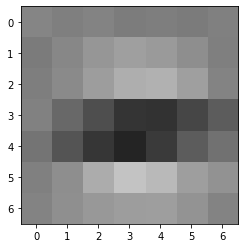

Green


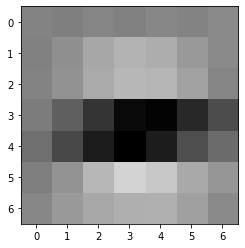

Blue


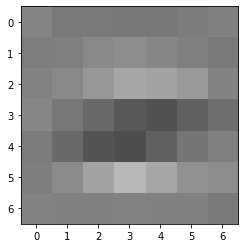

In [59]:
# Question 1a.

import torch
from torchvision import models
import matplotlib.pyplot as plt

#... code for loading resnet model not shown
print("Red")
ind = 28
filt = resnet.conv1.weight[ind].detach().numpy()
scale = 1/max(filt.max(), -1.*filt.min())
filt = filt * scale
plt.imshow(filt[0,:,:],cmap='gray',vmin=-1,vmax=1)
plt.show()

print("Green")
ind = 28
filt = resnet.conv1.weight[ind].detach().numpy()
scale = 1/max(filt.max(), -1.*filt.min())
filt = filt * scale
plt.imshow(filt[1,:,:],cmap='gray',vmin=-1,vmax=1)
plt.show()

print("Blue")
ind = 28
filt = resnet.conv1.weight[ind].detach().numpy()
scale = 1/max(filt.max(), -1.*filt.min())
filt = filt * scale
plt.imshow(filt[2,:,:],cmap='gray',vmin=-1,vmax=1)
plt.show()



### Bobby Horizontal Edge Detection

28


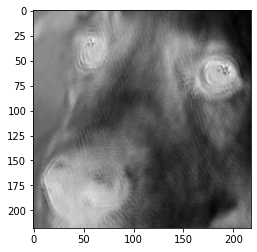

In [63]:
from torchvision import transforms
preprocess = transforms.Compose([
    transforms.Resize(356),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
    mean=[0.485,0.456,0.406],
    std=[0.229,0.224,0.225])
])
img = Image.open("data/dlwpt-code-master/data/p1ch2/bobby.jpg")
img_t = preprocess(img)
batch_t = torch.unsqueeze(img_t, 0)
ind =28
print(ind)
filt = resnet101.conv1.weight[ind].detach().unsqueeze(0)
filt_img = torch.conv2d(batch_t,filt)
filt_img = filt_img.squeeze(0).squeeze(0).detach().numpy()
plt.imshow(filt_img, cmap = 'gray')
plt.show()

#### Comments:
#### From this code we can see that the Horizontal edge detections sensitivity to color is note great as it shows all the colors being absent towards the center of the image. This can clearly be seen in Bobby as well since Bobby is a golde retriever and should be a much lighter color but is shown to be much darker in this image

## Question 1b.

### RGB Filters For Vertical Edge Filter

Red


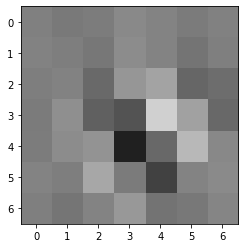

Green


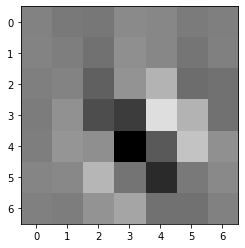

Blue


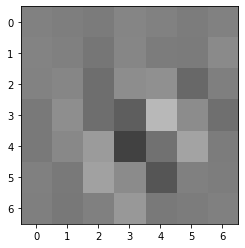

In [60]:
# Question 1a. 
import torch
from torchvision import models
import matplotlib.pyplot as plt

#... code for loading resnet model not shown
print("Red")
ind = 34
filt = resnet.conv1.weight[ind].detach().numpy()
scale = 1/max(filt.max(), -1.*filt.min())
filt = filt * scale
plt.imshow(filt[0,:,:],cmap='gray',vmin=-1,vmax=1)
plt.show()

print("Green")
ind = 34
filt = resnet.conv1.weight[ind].detach().numpy()
scale = 1/max(filt.max(), -1.*filt.min())
filt = filt * scale
plt.imshow(filt[1,:,:],cmap='gray',vmin=-1,vmax=1)
plt.show()

print("Blue")
ind = 34
filt = resnet.conv1.weight[ind].detach().numpy()
scale = 1/max(filt.max(), -1.*filt.min())
filt = filt * scale
plt.imshow(filt[2,:,:],cmap='gray',vmin=-1,vmax=1)
plt.show()




### Bobby Vertical Edge Detector

34


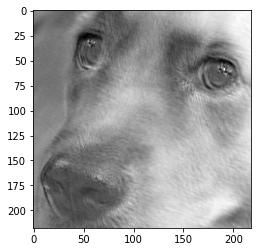

In [64]:
from torchvision import transforms
preprocess = transforms.Compose([
    transforms.Resize(356),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
    mean=[0.485,0.456,0.406],
    std=[0.229,0.224,0.225])
])
img = Image.open("data/dlwpt-code-master/data/p1ch2/bobby.jpg")
img_t = preprocess(img)
batch_t = torch.unsqueeze(img_t, 0)
ind =34
print(ind)
filt = resnet101.conv1.weight[ind].detach().unsqueeze(0)
filt_img = torch.conv2d(batch_t,filt)
filt_img = filt_img.squeeze(0).squeeze(0).detach().numpy()
plt.imshow(filt_img, cmap = 'gray')
plt.show()

#### Comments:
#### The vertical edge detection does a significantly better job than the horizontal detectro as it presents a more resonable image with lighter shaedes and colors but still has some amount of darkness especially on the left side of the image that is not present in the original image

## Question 1c.

### RGB Filters For Low Pass Filter

Red


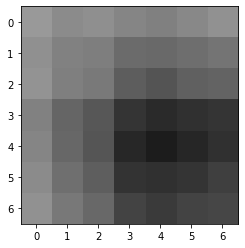

Green


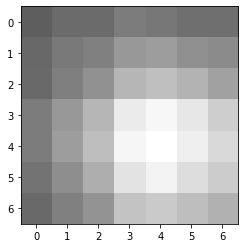

Blue


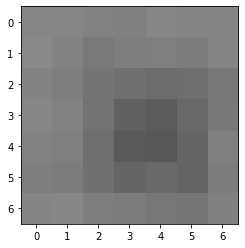

In [67]:
# Question 1a. 
import torch
from torchvision import models
import matplotlib.pyplot as plt

#... code for loading resnet model not shown
print("Red")
ind = 4
filt = resnet.conv1.weight[ind].detach().numpy()
scale = 1/max(filt.max(), -1.*filt.min())
filt = filt * scale
plt.imshow(filt[0,:,:],cmap='gray',vmin=-1,vmax=1)
plt.show()

print("Green")
ind = 4
filt = resnet.conv1.weight[ind].detach().numpy()
scale = 1/max(filt.max(), -1.*filt.min())
filt = filt * scale
plt.imshow(filt[1,:,:],cmap='gray',vmin=-1,vmax=1)
plt.show()

print("Blue")
ind = 4
filt = resnet.conv1.weight[ind].detach().numpy()
scale = 1/max(filt.max(), -1.*filt.min())
filt = filt * scale
plt.imshow(filt[2,:,:],cmap='gray',vmin=-1,vmax=1)
plt.show()



### Bobby Low Pass Filter

4


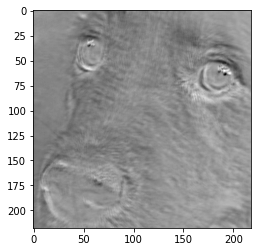

In [66]:
from torchvision import transforms
preprocess = transforms.Compose([
    transforms.Resize(356),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
    mean=[0.485,0.456,0.406],
    std=[0.229,0.224,0.225])
])
img = Image.open("data/dlwpt-code-master/data/p1ch2/bobby.jpg")
img_t = preprocess(img)
batch_t = torch.unsqueeze(img_t, 0)
ind =4
print(ind)
filt = resnet101.conv1.weight[ind].detach().unsqueeze(0)
filt_img = torch.conv2d(batch_t,filt)
filt_img = filt_img.squeeze(0).squeeze(0).detach().numpy()
plt.imshow(filt_img, cmap = 'gray')
plt.show()

#### Comments:
#### This image does the worst job of the three as it ignores any sort of high freqeucny signal, I.E. shrap transitions form dark to light or vicer versa with which a lighter image about a light color fur dog erases a lot of the color and detail from the image

## Question 2a


### Image Before Filter

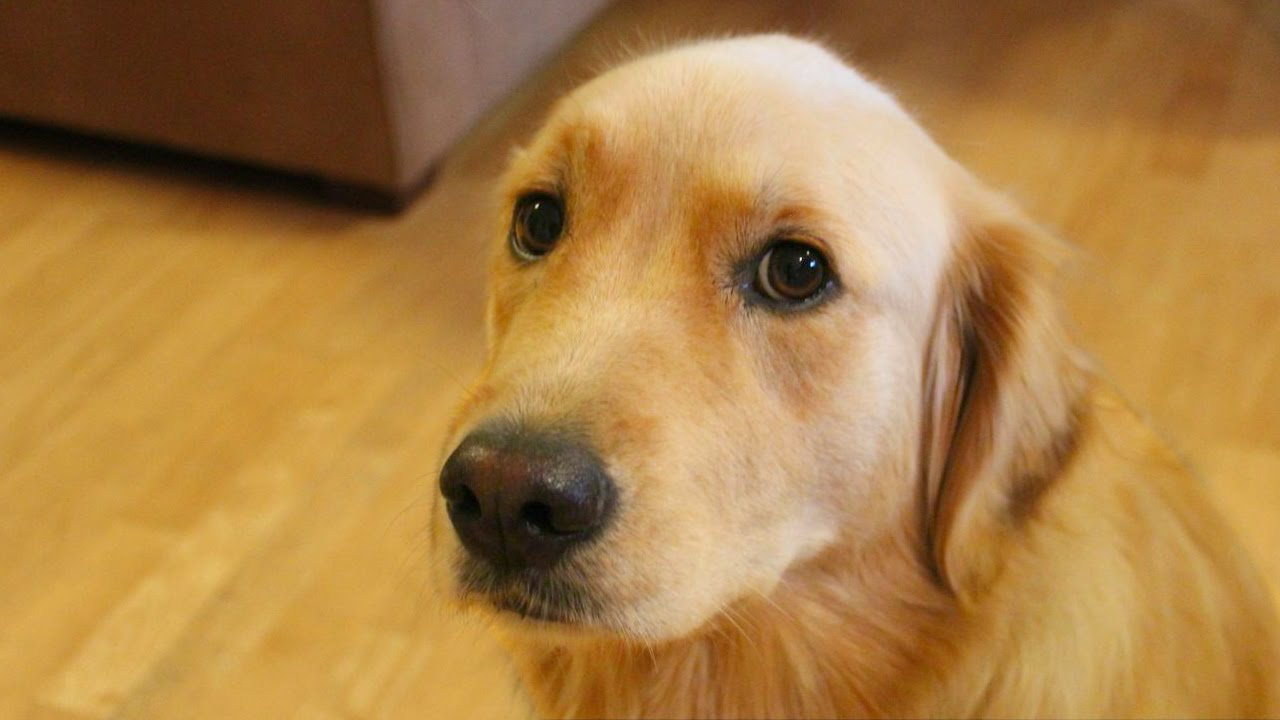

In [28]:
from PIL import Image
from torchvision import transforms

preprocess = transforms.Compose([transforms.Resize(256),
                                 transforms.ToTensor()])
img = Image.open("data/dlwpt-code-master/data/p1ch2/bobby.jpg")
img

### Image After Filter

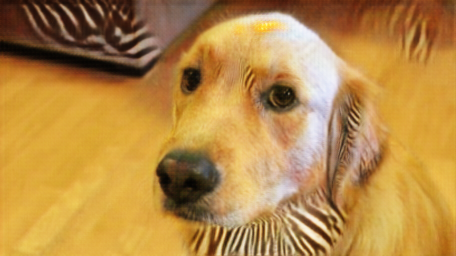

In [29]:
# Question 2a
img_t = preprocess(img)
batch_t = torch.unsqueeze(img_t, 0)
batch_out = netG(batch_t)
out_t = (batch_out.data.squeeze() + 1.0) / 2.0
out_img = transforms.ToPILImage()(out_t)
out_img

## Question 2b.

#### The picture did not do as good of a job as it did with the horse. With the picture of the horse it recognized the entire horse and perfectly added in the zebra stripes and coloration overlay to the horse. With the dog however, it only replaced a portion of the dog and event eh background with what it recognized as a horse while leaving the rest of the orignial image intact